In [4]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.metrics import recall_score, f1_score, precision_score
from sklearn.model_selection import train_test_split

data = pd.read_csv('creditcard.csv')

df = pd.DataFrame(data)

df = df.dropna()
model = XGBClassifier(n_estimators=700, scale_pos_weight=15, learning_rate=0.01, max_depth=5)

X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.25)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=700,
              n_jobs=None, num_parallel_tree=None, ...)

Recall 0.8407079646017699
Precision 0.8407079646017699
F1 0.8407079646017699
Confusion Metrix: [[71071    18]
 [   18    95]]


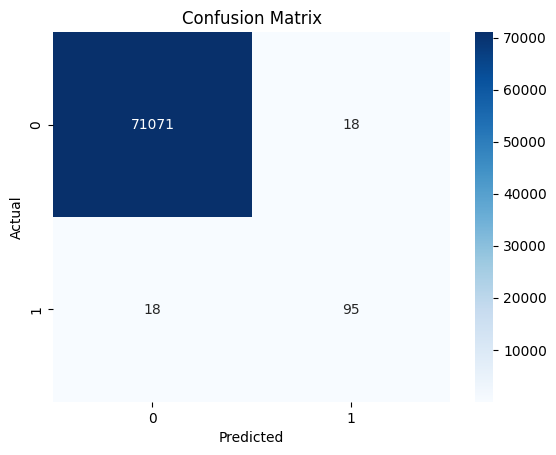

ROC-AUC SCORE: 0.9827414395291856


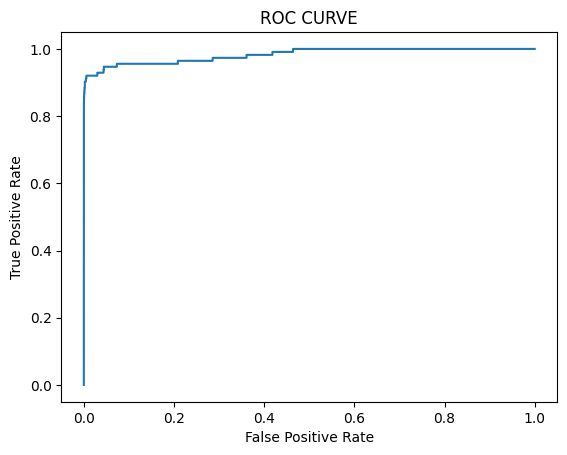

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

print("Recall", recall_score(y_test, y_pred))
print("Precision", precision_score(y_test, y_pred))
print("F1", f1_score(y_test, y_pred))
print("Confusion Metrix:", confusion_matrix(y_test, y_pred))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

y_proba = model.predict_proba(X_test)[:, 1]
rac = roc_auc_score(y_test, y_proba)

print("ROC-AUC SCORE:", rac)

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title("ROC CURVE")
plt.show()

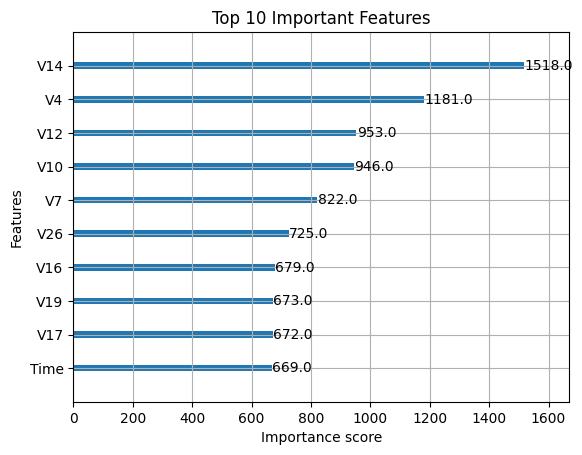

In [7]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

plot_importance(model, max_num_features=10)
plt.title("Top 10 Important Features")
plt.show()